## “Automatic” reshaping (自动重塑)
要更改数组的维度，您可以省略其中一个大小参数，数组的下一个大小参数将自动推导得出：

In [2]:
import numpy as np
a = np.arange(30)
b = a.reshape((2, -1, 3))  # -1 means "whatever is needed"
print (b.shape)
print (b)


(2, 5, 3)
[[[ 0  1  2]
  [ 3  4  5]
  [ 6  7  8]
  [ 9 10 11]
  [12 13 14]]

 [[15 16 17]
  [18 19 20]
  [21 22 23]
  [24 25 26]
  [27 28 29]]]


## Vector stacking（向量堆叠）
如何从一个等长的行向量列表构造一个二维数组？
在 MATLAB 中这相当简单：如果 x 和 y 是两个长度相同的向量，你只需要执行 m=[x;y] 即可。
在 NumPy 中，这可以通过函数 column_stack、dstack、hstack 和 vstack 来实现，具体取决于要沿哪个维度进行堆叠。例如：

In [3]:
x = np.arange(0, 10, 2)
y = np.arange(5)
m = np.vstack([x, y])
print (m)
xy = np.hstack([x, y])
print (xy)

[[0 2 4 6 8]
 [0 1 2 3 4]]
[0 2 4 6 8 0 1 2 3 4]


## Histograms(直方图)
对数组应用 NumPy 的 histogram 函数会返回一对向量：数组的直方图以及一个 bin 边界向量。请注意：matplotlib 也有一个用于构建直方图的函数（名为 hist，与 Matlab 中一样），它与 NumPy 中的函数有所不同。主要区别在于，pylab.hist 会自动绘制直方图，而 numpy.histogram 仅生成数据。
**如果要分别查看每个图，可以在每次绘图后调用 plt.show() 或分别新建图形窗口。**

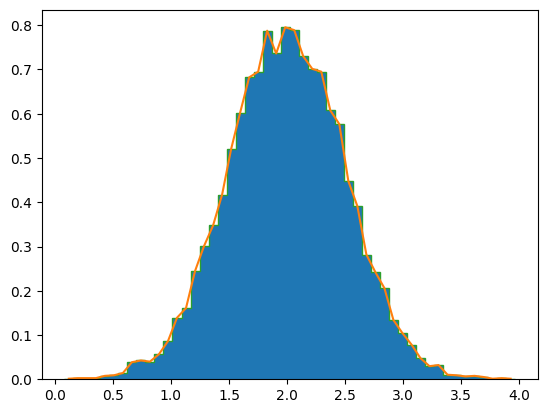

In [21]:
import numpy as np
# 创建一个随机数生成器对象，种子为 1，保证结果可重复
rg = np.random.default_rng(1)
import matplotlib.pyplot as plt
# Build a vector of 10000 normal deviates with variance 0.5^2 and mean 2
# 生成 10000 个服从正态分布的随机数，均值 mu=2，标准差 sigma=0.5
mu, sigma = 2, 0.5
v = rg.normal(mu, sigma, 10000)
# Plot a normalized histogram with 50 bins
# ==================== 方法一：使用 matplotlib 直接绘制直方图 ====================
# plt.hist() 会自动计算频数分布并绘制条形图
# bins=50      : 将数据范围等分为 50 个区间（条形）
# density=True : 归一化，使条形总面积等于 1（纵轴表示概率密度，而非频数）
plt.hist(v, bins=50, density=True)       # matplotlib version (plot)
#plt.show()
# Compute the histogram with numpy and then plot it
# ==================== 方法二：使用 numpy 计算直方图数据，再用 plt 绘制 ====================
# np.histogram() 只计算直方图数据，不绘图
# 返回 (n, bins)：
#   n   : 每个区间内的频数（归一化后，即概率密度值）
#   bins: 区间的边界（长度为 51，因为有 50 个区间）
(n, bins) = np.histogram(v, bins=50, density=True)  # NumPy version (no plot)
# 计算每个区间的中点：bins 相邻两个值的平均值
# bins[1:]   : 右边界（第 1 到第 50 个）
# bins[:-1]  : 左边界（第 0 到第 49 个）
# .5 * (右 + 左) 得到每个区间的中点坐标
#midpoints = 0.5 * (bins[1:] + bins[:-1])
# 绘制折线图，将每个区间的中点与对应的概率密度值 n 连接起来
# 折线可以更直观地展示分布的形状（类似于概率密度曲线的近似）
plt.plot(.5 * (bins[1:] + bins[:-1]), n) 
#plt.show()
# plt.stairs() 专门绘制阶梯图（步状图），通常用于直方图的可视化
# 参数 n 是每个区间的值，bins 是边界，画出的图形与 plt.hist 的条形图一致
plt.stairs(n, bins)